# Table of Contents
<span style="font-size:16px;">
    
**1.** Data Description <br>
**2.** Data Loading <br>
**3.** Data Preprocessing <br>
**4.** Exploratory Data Analysis (EDA)<br>
**5.** Feature Engineering <br>
**6.** Model Selection <br>
**7.** Model Evaluation <br>
**8.** Sanity Check <br>
**9.** Conclusion <br>
**10.** Summary <br>

</span>

# Task Description
## Introduction ##

<span style="font-size:16px;">	
    
`Sweet Lift Taxi` company has collected historical data on taxi orders at airports.  
To attract more drivers during peak hours, we need to predict **the amount of taxi orders** for the next hour. Build a model for such a prediction.

The **`RMSE`** metric on the test set should not be more than **48**.

</span>

# Project instructions
<span style="font-size:16px;">

The data is stored in file `taxi.csv`. The number of orders is in the **`num_orders`** column.

Download the data and resample it by one hour.  
Analyze the data.  
Train different models with different hyperparameters.  
The test sample should be 10% of the initial dataset.  
Test the data using the test sample and provide a conclusion.

</span>

# Imports

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  # nice background for charts
import re

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
import warnings
if not sys.warnoptions:
       warnings.simplefilter("ignore")

pd.set_option('display.max_rows', None, 'display.max_columns', None)

print("Setup Complete!")

Setup Complete!


# Data Load

In [2]:
try:
    df = pd.read_csv('C:/Users/elesg/OneDrive/Desktop/DS-project/taxi.csv', index_col=[0], parse_dates=[0])    
except:
    print("File not found. Check the path.")

In [3]:
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [5]:
df.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


## Notes for preprocessing:
<span style="font-size:16px;">
    
- There are more than **26k observations** with 1 feature and 1 target variable;  
- Data is collected for 6 months in 2018;  
- Check if the dates and times are **in chronological order**;  
- **Resample data by 1 hour** because we need to predict orders for the next hour. Take the sum as an aggregation function since we need to identify the total number of orders for a particular hour;  
- No missing values;  
- Need to check for **duplicates**;  
- The target is numeric, it's a **regression task**.

</span>

In [6]:
df.sort_index(inplace=True)

In [7]:
df.index.is_monotonic_increasing

True

<span style="font-size:16px;">

The dates and times are in chronological order.
</span>

In [8]:
df.sort_index(inplace=True)
df = df.resample('H').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [9]:
df.isna().sum()

num_orders    0
dtype: int64

In [10]:
df.query('num_orders >= 107').head(5)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 22:00:00,113
2018-03-02 01:00:00,120
2018-03-02 22:00:00,119
2018-03-03 00:00:00,163


<span style="font-size:16px;">

The dataset spans from **2018-03-01 00:00:00 to 2018-08-31 23:50:00**, originally recorded at 10-minute intervals. To align with the forecasting objective of predicting demand for the next hour, the data was resampled to an hourly frequency. The dataset contains **4,416 consecutive hourly observations** with no missing values, ensuring continuity for time-series modeling. On average, there are **84 trips per hour**, with a relatively high standard deviation of 45, indicating significant variability in demand (approximately 53% of the mean). Additionally, **25% of the observations exceed 107 trips**, suggesting frequent high-demand periods. An initial exploratory analysis also reveals a clear temporal pattern, with increased activity consistently observed **between 22:00 and 01:00**, indicating strong nightly peak demand behavior.

</span>

# Exploratory Data Analysis (EDA)
## Rolling Inspection

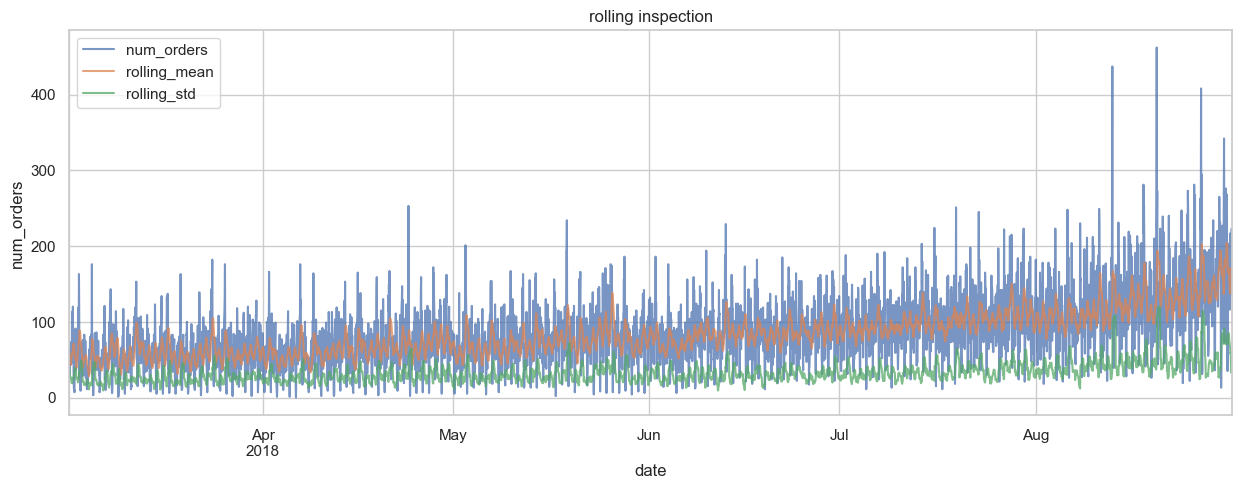

In [11]:
df['rolling_mean'] = df.shift(1).rolling(12).mean()
df['rolling_std'] = df['num_orders'].shift(1).rolling(12).std()
df = df.dropna()

df.plot(grid=True,alpha=0.75,figsize=(15,5))
plt.title('rolling inspection')
plt.xlabel('date')
plt.ylabel('num_orders');

<span style="font-size:16px;">	

We observe that the **standard deviation remains relatively stable** over time, indicating consistent variability in the data. However, the average value of the dataset increases by approximately a factor of two, suggesting a clear upward trend.  
As a result, the underlying stochastic process can be considered **slightly non-stationary**, as its mean is not constant over time, even though **the variance remains relatively unchanged**.

</span>

## One Month Slice

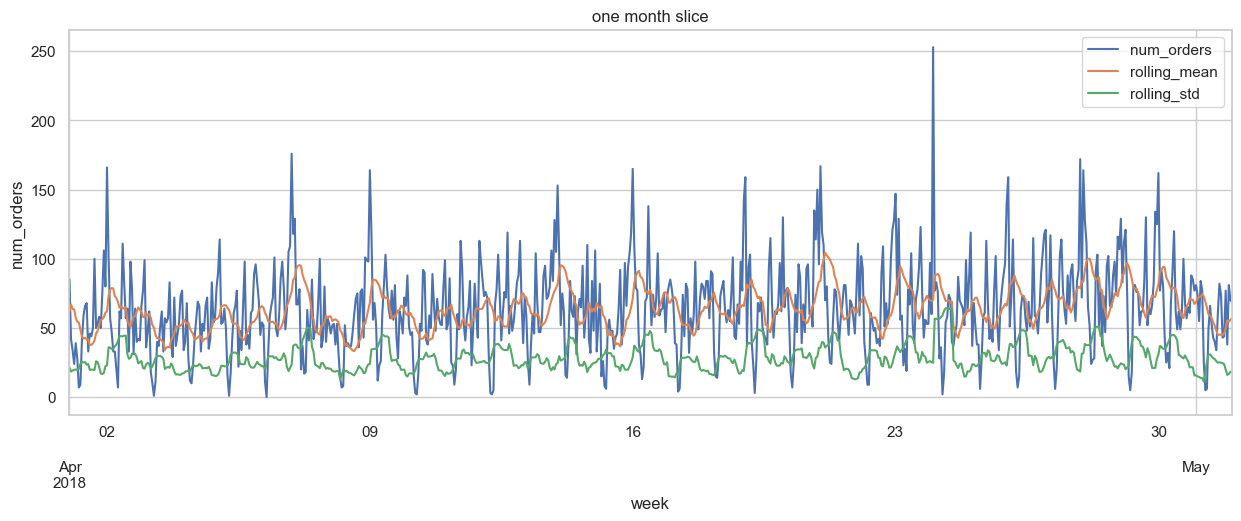

In [12]:
df['2018-04-01':'2018-05-01'].plot(grid=True,figsize=(15,5))
plt.title('one month slice')
plt.xlabel('week')
plt.ylabel('num_orders');

## One Week Slice

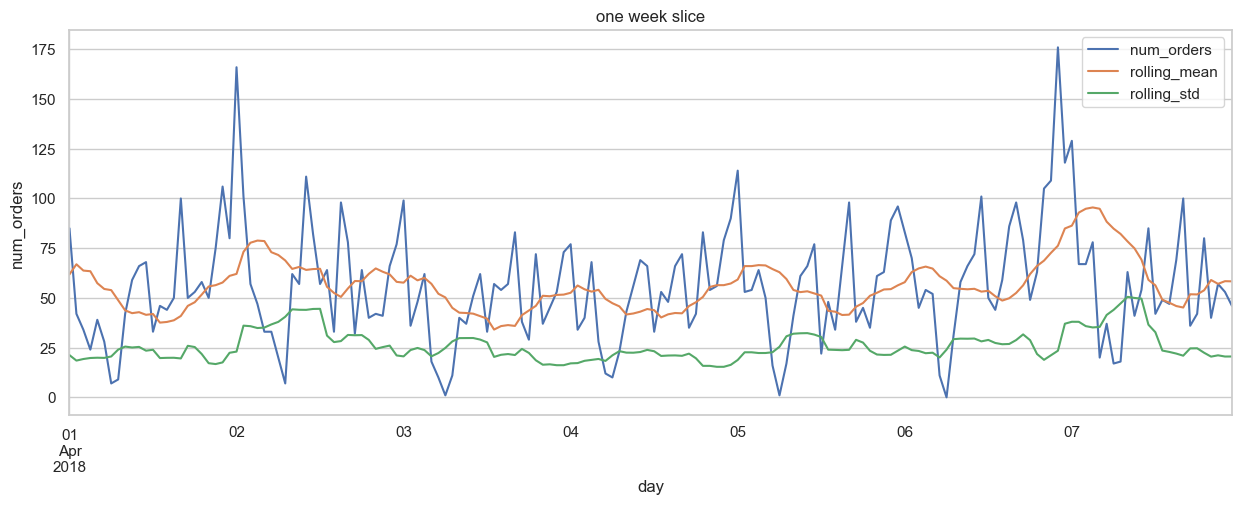

In [13]:
df['2018-04-01':'2018-04-07'].plot(grid=True,figsize=(15,5))
plt.title('one week slice')
plt.xlabel('day')
plt.ylabel('num_orders');

## Seasonal Decomposition

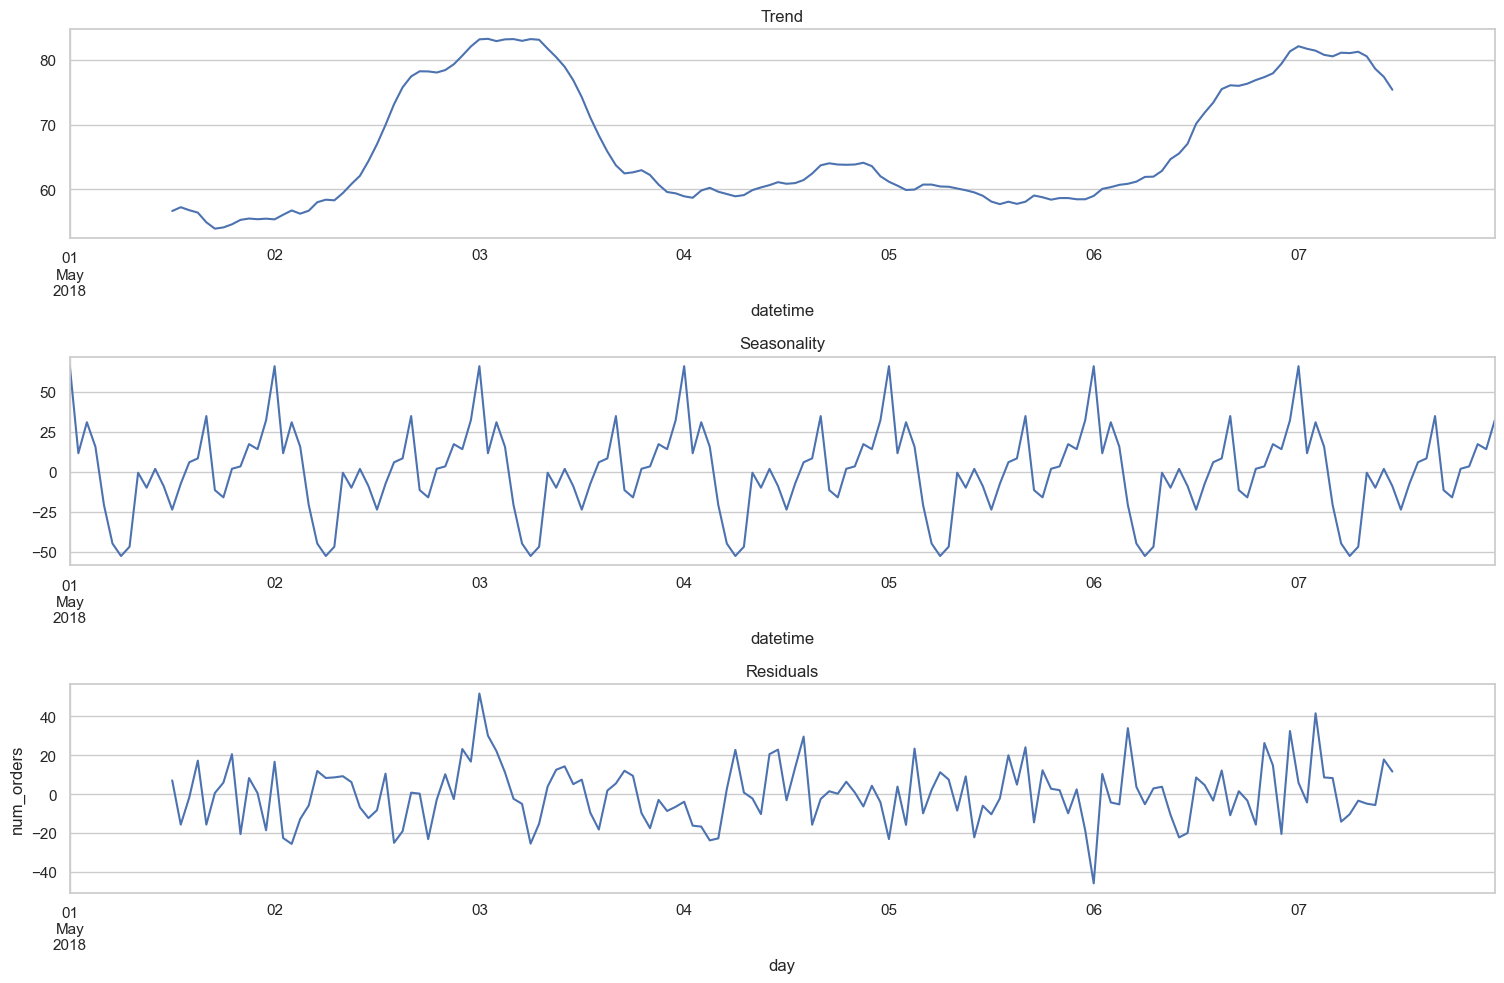

In [14]:
decomposed = seasonal_decompose(df['num_orders']['2018-05-01':'2018-05-07'])

plt.figure(figsize=(15,10))
plt.subplot(311)
decomposed.trend['2018-05-01':'2018-05-07'].plot(ax=plt.gca(),grid=True)
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal['2018-05-01':'2018-05-07'].plot(ax=plt.gca(),grid=True)
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid['2018-05-01':'2018-05-07'].plot(ax=plt.gca(),grid=True)
plt.title('Residuals')
plt.tight_layout()
plt.xlabel('day')
plt.ylabel('num_orders');

The trend component **does not show** a single consistent direction, but rather a recurring weekly pattern. There is a **noticeable increase around the third day of the week**, followed by a slight decrease and a relatively stable pattern throughout the remaining weekdays. Additionally, demand tends to **rise again during the weekend**, indicating a clear cyclical behavior.

Strong seasonality is also present in the data. **A consistent peak in activity is observed around midnight (00:00)**, while the lowest values typically occur in the **early morning hours around 06:00**. Overall, the dataset exhibits clear and regular seasonal patterns both within the day and across the week, suggesting strong temporal dependencies in the observed process.

## Feature Engineering

In [15]:
def make_features(df, max_lag):
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['dayofweek'] = df.index.dayofweek
    df['hour'] = df.index.hour
    
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
    
    df.dropna(inplace=True)

In [16]:
make_features(df, 12)
df.columns

Index(['num_orders', 'rolling_mean', 'rolling_std', 'month', 'day',
       'dayofweek', 'hour', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5',
       'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12'],
      dtype='object')

In [17]:
df.head(2)

,num_orders,rolling_mean,rolling_std,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
datetime,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,56.583333,22.386921,3,2,4,0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0
2018-03-02 01:00:00,120,61.583333,22.609163,3,2,4,1,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0


## Key Insights:

<span style="font-size:16px;">	

The features extracted from the dataset include month, day, day of the week, and hour. Since all observations originate from the year 2018, the year feature was excluded as it does not provide meaningful variability or predictive value.

**Cyclical Features**

To capture temporal patterns, the following cyclical features were created:

- Month
- Day
- Day of the week
- Hour

These features help the model learn recurring temporal behaviors across daily and weekly cycles.

**Lag Features**

A total of 12 lag features were introduced to capture short-term temporal dependencies. This choice was made to balance model complexity and computational efficiency, avoiding excessive feature noise while maintaining predictive power. Additional lag features can be incorporated if further performance improvement is required.

**Rolling Features**

Rolling statistics, including rolling mean and rolling standard deviation, were also engineered to capture local trends and variability in the time series. These features were computed using the shift() function to ensure that no future information is included, thereby preventing data leakage.

</span>

# Model Preparation
<span style="font-size:16px;">	

For this project, we train multiple machine learning models:
- **`Random Forest`**
- **`Linear Regression`**
- **`XGBoost`**
- **`LightGBM`**
- **`CatBoost`**

Hyperparameter optimization is performed using **`RandomizedSearchCV`** to identify the best-performing configuration for each model. The evaluation metric used is **`RMSE`**, and model performance is assessed on a held-out test set.

In accordance with the project requirements, **10% of the data is reserved as the test set**. The primary objective is to achieve an **RMSE below 48** on the test data. After model selection, a final sanity check is conducted by comparing the best-performing model against a **baseline Dummy Regressor**, ensuring that the trained model provides a meaningful improvement over a naive prediction strategy.

</span>

In [18]:
train, test = train_test_split(df, shuffle=False, test_size=0.1)
train = train.dropna()

X_train = train.drop('num_orders',axis=1)
y_train = train['num_orders']
X_test = test.drop('num_orders',axis=1)
y_test = test['num_orders']

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
def RMSE(true, pred):
    rmse = mean_squared_error(true, pred)
    rmse = rmse ** 0.5
    
    return rmse

In [21]:
rmse_scorer = make_scorer(RMSE, greater_is_better = False)

In [22]:
tscv = TimeSeriesSplit()

## Dummy Regressor (Baseline)

In [23]:
Dummy = DummyRegressor(strategy='median')

baseline_rmse = cross_val_score(Dummy, 
                                       X_train, y_train, cv=tscv, 
                                       scoring = rmse_scorer
                               )
print(f"""
- Dummy Regression Result -

Baseline_rmse: {-baseline_rmse.mean():.2f}
""")


- Dummy Regression Result -

Baseline_rmse: 41.43



## Linear Regression

In [24]:
LR = LinearRegression()

LR_rmse = cross_val_score(
    LR, 
    X_train, 
    y_train, 
    cv=tscv, 
    scoring=rmse_scorer
)

LR.fit(X_train, y_train)

print(f"""
- Linear Regression Result -

Score: {-LR_rmse.mean():.2f}
""")


- Linear Regression Result -

Score: 31.24



## Random Forest

In [25]:
param_rf = {
    'n_estimators': [300, 500],             
    'max_depth': [None, 10, 20],           
    'min_samples_split': [2, 5],      
    'min_samples_leaf': [1, 2]    
}

In [26]:
RF = RandomForestRegressor(random_state=34)

random_rf = RandomizedSearchCV(
    estimator=RF,
    param_distributions=param_rf, 
    n_iter=20,                     
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=34
)

random_rf.fit(X_train, y_train)

model_RF_best = random_rf.best_estimator_
score_RF_best = random_rf.best_score_

print(f"""
- Random Forest Randomized Search Result -

Best Score:     {-random_rf.best_score_:.2f}
Best Params:    {random_rf.best_params_}
""")


- Random Forest Randomized Search Result -

Best Score:     25.05
Best Params:    {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}



## XGBoost

In [27]:
param_xgb = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [28]:
XGB = XGBRegressor(
    random_state=34,
    n_jobs=-1
)

random_search_xgb = RandomizedSearchCV(
    estimator=XGB,
    param_distributions=param_xgb,
    n_iter=30,           
    cv=tscv,
    scoring=rmse_scorer, 
    verbose=0, 
    random_state=34,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

model_XGB_best = random_search_xgb.best_estimator_
score_XGB_best = random_search_xgb.best_score_

print(f"""
- XGBoost Randomized Search Result -

Best Score:     {-random_search_xgb.best_score_:.2f}
Best Params:    {random_search_xgb.best_params_}
""")


- XGBoost Randomized Search Result -

Best Score:     24.92
Best Params:    {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}



## LightGBM

In [29]:
param_lgbm = {
    'n_estimators': [300, 500],
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1]
}

In [30]:
LGBM = LGBMRegressor(verbose=-1,
    random_state=34,
    n_jobs=-1
)

random_search_lgbm = RandomizedSearchCV(
    estimator=LGBM,
    param_distributions=param_lgbm,
    n_iter=30,           
    cv=tscv,
    scoring=rmse_scorer, 
    verbose=0, 
    random_state=34,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

model_LGBM_best = random_search_lgbm.best_estimator_
score_LGBM_best = random_search_lgbm.best_score_

print(f"""
- LightGBM Randomized Search Result -

Best Score:     {-random_search_lgbm.best_score_:.2f}
Best Params:    {random_search_lgbm.best_params_}
""")


- LightGBM Randomized Search Result -

Best Score:     24.68
Best Params:    {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 500, 'learning_rate': 0.01, 'colsample_bytree': 0.7}



## CatBoost

In [31]:
param_cat = {
    "iterations": [300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [3, 4, 5],
    "l2_leaf_reg": [3, 5, 7, 9],
    "bagging_temperature": [0, 0.5, 1],
    "random_strength": [1, 3, 5],
    "border_count": [32, 64],
    "subsample": [0.7, 0.8, 1.0]
}

In [32]:
CAT = CatBoostRegressor(verbose=0, 
    random_state=34
)

random_search_cat = RandomizedSearchCV(
    estimator=CAT,
    param_distributions=param_cat,
    n_iter=30,           
    cv=tscv,
    scoring=rmse_scorer, 
    verbose=0, 
    random_state=34,
    n_jobs=-1
)

random_search_cat.fit(X_train, y_train)

model_CAT_best = random_search_cat.best_estimator_
score_CAT_best = random_search_cat.best_score_

print(f"""
- CatBoost Randomized Search Result -

Best Score:     {-random_search_cat.best_score_:.2f}
Best Params:    {random_search_cat.best_params_}
""")


- CatBoost Randomized Search Result -

Best Score:     24.65
Best Params:    {'subsample': 0.7, 'random_strength': 3, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 4, 'border_count': 64, 'bagging_temperature': 1}



## Results

In [40]:
results = pd.DataFrame({
    'model': [
        'DummyRegressor (Baseline)',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],
    
    'rmse_scores': [
        -baseline_rmse.mean(),
        -LR_rmse.mean(),
        -random_rf.best_score_,
        -random_search_xgb.best_score_,
        -random_search_lgbm.best_score_,
        -random_search_cat.best_score_
    ]
})

print(results.sort_values(by='rmse_scores').reset_index(drop=True))

                       model  rmse_scores
0                   CatBoost    24.645093
1                   LightGBM    24.680622
2                    XGBoost    24.924271
3              Random Forest    25.054322
4          Linear Regression    31.243998
5  DummyRegressor (Baseline)    41.425737


### RMSE Summary & Key Insights:

<span style="font-size:16px;">	
    
The results show that **all gradient boosting models perform very similarly**, with close `RMSE` values **around 24.6–24.9**. This indicates that these models are consistently **capturing the underlying nonlinear patterns** in the data.   
**`CatBoost`** performs slightly better and is the best overall model, but the improvement over LightGBM and XGBoost is minimal.   
**`Random Forest`** also shows competitive performance but is slightly weaker than gradient boosting methods.   
**`Linear Regression`** performs significantly worse, highlighting the importance of nonlinear modeling for this problem.   
**`Dummy Regressor`** has the highest error, confirming that all trained models provide strong predictive value.
</span>

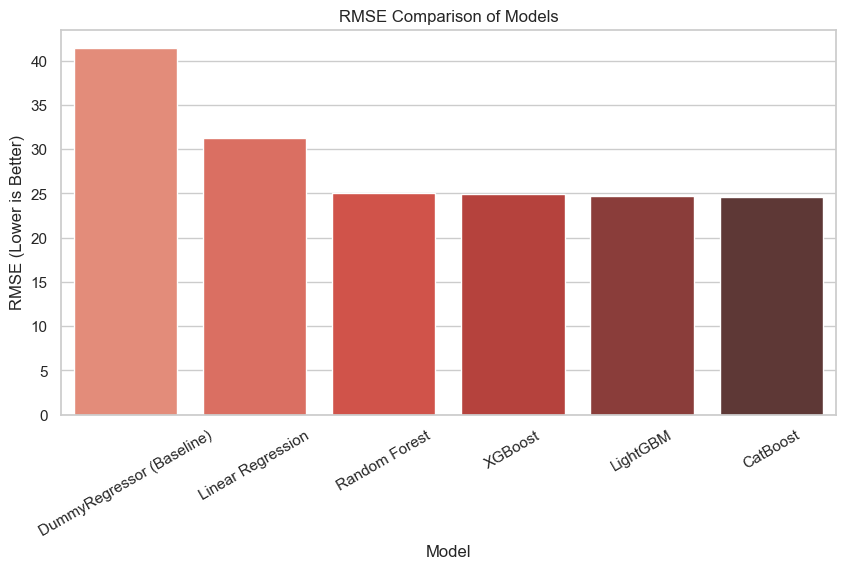

In [42]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x="model", y="rmse_scores", data=results, palette="Reds_d")
plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()

## Test Set

In [52]:
# CatBoost with optimal hyperparameters identified during training.

best_model = random_search_cat.best_estimator_

y_pred = best_model.predict(X_test)

final_rmse = RMSE(y_test, y_pred)

print(f"""
- Best Model (CatBoost) on Test Set -

Final Score:   {final_rmse:.2f}
""")


- Best Model (CatBoost) on Test Set -

Final Score:   41.48



## Sanity Check

In [51]:
Dummy.fit(X_train, y_train)

y_pred = Dummy.predict(X_test)

rmse_sanity = RMSE(y_test, y_pred)

print(f"""
- Sanity Check on Test Set -

Dummy Score:   {rmse_sanity:.2f}
""")


- Sanity Check on Test Set -

Dummy Score:   87.21



## Final Model Performance on Test set:
<span style="font-size:16px;">	
    
On the test set, the **`CatBoost`** model achieved an **`RMSE 41.48`**, which is a strong result and successfully meets the project requirement of staying **below 48 RMSE**. In comparison, `Dummy Regressor` **scored 87.21**, showing that the trained model reduces error by **more than 50%** relative to a naive baseline. This significant improvement confirms that the model is learning meaningful patterns from the data rather than relying on simple averages.   
The large gap between the two models highlights the effectiveness of the feature engineering and gradient boosting approach.   
Overall, **`CatBoost`** model demonstrates strong predictive performance and clear superiority over the baseline.
</span>

# Summary

<span style="font-size:16px;">

In this project, we developed a **time series regression model** to predict the number of taxi orders for the next hour for the *Sweet Lift Taxi* company. The objective was to build a model with a **test RMSE below 48**, enabling better driver allocation during peak demand periods.

### Preprocessing:
- Verified that **date and time are in chronological order**.  
- **Resampled the data to hourly frequency** using sum aggregation to match the prediction target (orders per hour).  
- Confirmed there are **no missing values or duplicates** in the dataset.  
- Defined the problem as a **regression task** with a numeric target (`num_orders`).  

### Data Overview:
- The dataset spans from **2018-03-01 to 2018-08-31**, originally at 10-minute intervals.  
- After resampling, it contains **4,416 consecutive hourly observations**.  
- The average demand is **84 orders per hour**, with a **standard deviation of 45**, indicating high variability.  
- Around **25% of observations exceed 107 orders**, showing frequent peak demand periods.  
- Clear temporal patterns were observed, with **higher demand between 22:00 and 01:00**.  

### Exploratory Data Analysis (EDA):
- The **standard deviation remains stable**, while the **mean increases over time**, indicating slight **non-stationarity**.  
- Weekly patterns show fluctuations with increased demand mid-week and during weekends.  
- Strong **daily seasonality** was identified, with peaks at night and lows in the early morning.  
- Seasonal decomposition confirmed consistent recurring patterns.  

### Feature Engineering:
- Created **time-based (cyclical) features**:
  - Month, Day, Day of Week, Hour  
- Generated **lag features (12 lags)** to capture temporal dependencies.  
- Added **rolling statistics** (mean and standard deviation) using `shift()` to prevent data leakage.  

### Model Selection & Tuning:
- Trained and evaluated multiple models:
  - `Linear Regression`  
  - `Random Forest`  
  - `XGBoost`  
  - `LightGBM`  
  - `CatBoost`  
- Applied **RandomizedSearchCV** for hyperparameter tuning.  
- Used **RMSE** as the evaluation metric.  
- Reserved **10% of the data as a test set**, following project requirements.  

### Results:
- Gradient boosting models (**CatBoost, LightGBM, XGBoost**) showed **very similar and strong performance**.  
- **CatBoost** achieved the best validation result.  

- On the **test set**:
  - **CatBoost RMSE: 41.48**  
  - **Dummy Regressor RMSE: 87.21**  

### Insights:
- The final model significantly **outperformed the baseline**, reducing error by more than **50%**, confirming that it captures meaningful patterns in the data.  
- The achieved RMSE is **well below the required threshold of 48**, indicating successful model performance.  
- Tree-based and boosting models clearly outperform linear models, highlighting the **nonlinear nature of the problem**.  
- Feature engineering, particularly **lag and temporal features**, played a crucial role in model success.  

</span>